# Comment : 
- Created a function to identifiy grayscale images in test dataset, and predict with color or 
grayscale model accordingl
- • Re-computed weights for each models by level of occlusion for color and grayscale datas
- 
• Trained color model on 87k images, and grasycale model on 14k image - •
⇒ 0.0016 with 3 epo, 
⇒ 0.0013 with 10 , chs
⇒ 0.00089 with 30
- epochs
Ensemble learning with 2 models gave best results, with a weighted MSE loss
function (rebalancing only occlusi
- Face parsing in the next fileon level)

# 1-Package

In [1]:
# Data processing
import pandas as pd
import numpy as np
from collections import OrderedDict
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
from tqdm import tqdm

# Image handling
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import mobilenet_v3_small

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
from functions import Dataset

### Load dataframes

In [3]:
df_train = pd.read_csv("df_train_without_val.csv")
df_val = pd.read_csv("df_val.csv")
df_test = pd.read_csv("df_test.csv")

image_dir = "Data/crops_100K"

df_train = df_train.dropna()
df_test = df_test.dropna()

print("Training set:")
print(df_train.head())
print("\nValidation set:")
print(df_val.head())

Training set:
                                            filename  FaceOcclusion  gender  \
0                          database1/img00015966.jpg          0.015   0.997   
1  database3/database3/m.01bczm/134-FaceId-0_alig...          0.011   0.998   
2  database3/database3/m.01bldq/0-FaceId-0_align.jpg          0.071   0.997   
3                          database1/img00017957.jpg          0.351   0.001   
4                          database1/img00020727.jpg          0.128   0.001   

   initial_index  gender_id  db_number  count  color  image_width  \
0           3803          1          1      1      1          224   
1          83938          1          3      1      1          224   
2          85474          1          3      1      1          224   
3           1978          0          1      1      1          224   
4           1200          0          1      1      1          224   

   image_height  ...  pixels  pixels_mean  pixels_mean_R  pixels_mean_G  \
0           224  ... 

### Make Dataset and Dataloader

We have already the function to make Dataloader.  Let's make a concise definition of DataLoader.

A DataLoader in PyTorch is a tool that helps you load data in small groups called batches.
It can shuffle the data, load it faster, and feed it to our model automatically during training or testing.

In [4]:
# Create training and validation datasets using the custom Dataset class
training_set = Dataset(df_train, image_dir)
validation_set = Dataset(df_val, image_dir)

# Define DataLoader parameters for training (with shuffling) and validation
params_train = {'batch_size': 8,
          'shuffle': True,
          'num_workers': 0}
params_val = {'batch_size': 8,
          'shuffle': False,
          'num_workers': 0}

# Create DataLoaders to load data in batches during training/validation
training_generator = torch.utils.data.DataLoader(training_set, **params_train)
validation_generator = torch.utils.data.DataLoader(validation_set, **params_val)

In [5]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")
torch.backends.cudnn.benchmark = True

The histogramme also shows the gender differences between dataset(mainly on data distribution), so we tried to handel this problem by adding gender based weights in weighted loss function.

## 2 model black and white / color

In [6]:
df_train

,filename,FaceOcclusion,gender,initial_index,gender_id,db_number,count,color,image_width,image_height,...,pixels,pixels_mean,pixels_mean_R,pixels_mean_G,pixels_mean_B,pixels_std,pixels_std_R,pixels_std_G,pixels_std_B,no_color
0,database1/img00015966.jpg,0.015,0.997,3803,1,1,1,1,224,224,...,50176,88.466724,131.119200,77.212532,57.068439,63.031255,63.500490,54.124863,45.002906,0
1,database3/database3/m.01bczm/134-FaceId-0_alig...,0.011,0.998,83938,1,3,1,1,224,224,...,50176,181.345258,211.715163,173.839943,158.480668,46.079777,31.835334,40.716520,46.874981,0
2,database3/database3/m.01bldq/0-FaceId-0_align.jpg,0.071,0.997,85474,1,3,1,1,224,224,...,50176,120.124821,143.054747,112.964525,104.355190,59.365307,65.384368,53.289036,51.304478,0
3,database1/img00017957.jpg,0.351,0.001,1978,0,1,1,1,224,224,...,50176,118.354479,151.092335,116.278819,87.692283,80.419840,84.658265,73.950982,68.920510,0
4,database1/img00020727.jpg,0.128,0.001,1200,0,1,1,1,224,224,...,50176,63.989411,93.894651,55.730349,42.343232,60.185922,77.639362,45.963021,35.992681,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81067,database1/img00000048.jpg,0.088,0.002,9798,0,1,1,1,224,224,...,50176,121.412807,145.933773,115.296516,103.008131,66.349866,65.550296,61.466950,64.455161,0
81068,database3/database3/m.018gv8/80-FaceId-0_align...,0.010,0.998,68466,1,3,1,1,224,224,...,50176,77.736195,96.263353,80.316287,56.628946,46.403188,46.491872,40.453225,43.201638,0
81069,database1/img00001250.jpg,0.305,0.003,13264,0,1,1,1,224,224,...,50176,144.604725,191.607940,137.841498,104.364736,60.161101,46.129839,49.004752,49.541361,0
81070,database3/database3/m.01djcw/85-FaceId-0_align...,0.004,0.999,99693,1,3,1,1,224,224,...,50176,151.064938,165.638831,150.087651,137.468331,61.774150,58.988866,62.913884,60.100521,0


In [7]:
# Split the dataset using the existing 'no_color' column
df_train_grayscale = df_train[df_train['no_color'] == True].copy()
df_train_color = df_train[df_train['no_color'] == False].copy()

In [8]:
df_train_grayscale.head()

,filename,FaceOcclusion,gender,initial_index,gender_id,db_number,count,color,image_width,image_height,...,pixels,pixels_mean,pixels_mean_R,pixels_mean_G,pixels_mean_B,pixels_std,pixels_std_R,pixels_std_G,pixels_std_B,no_color
6,database3/database3/m.01dmm2/6-FaceId-0_align.jpg,0.227,0.000,100565,0,3,1,0,224,224,...,50176,109.152324,109.152324,109.152324,109.152324,59.725291,59.725291,59.725291,59.725291,1
14,database3/database3/m.019pkm/91-FaceId-0_align...,0.016,0.994,78930,1,3,1,0,224,224,...,50176,126.826929,126.826929,126.826929,126.826929,78.626822,78.626822,78.626822,78.626822,1
17,database3/database3/m.0183dl/55-FaceId-0_align...,0.209,0.998,65150,1,3,1,0,224,224,...,50176,80.266801,80.266801,80.266801,80.266801,54.481635,54.481635,54.481635,54.481635,1
30,database3/database3/m.0197gg/7-FaceId-0_align.jpg,0.088,1.000,76051,1,3,1,0,224,224,...,50176,147.579161,147.579161,147.579161,147.579161,69.129797,69.129797,69.129797,69.129797,1
41,database3/database3/m.015t_m/70-FaceId-0_align...,0.001,0.982,42296,1,3,1,0,224,224,...,50176,104.774673,104.774673,104.774673,104.774673,51.627458,51.627458,51.627458,51.627458,1


In [9]:
print(df_train.columns.tolist())

['filename', 'FaceOcclusion', 'gender', 'initial_index', 'gender_id', 'db_number', 'count', 'color', 'image_width', 'image_height', 'channels', 'pixels', 'pixels_mean', 'pixels_mean_R', 'pixels_mean_G', 'pixels_mean_B', 'pixels_std', 'pixels_std_R', 'pixels_std_G', 'pixels_std_B', 'no_color']


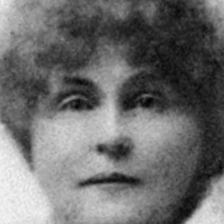

database3/database3/m.01dmm2/6-FaceId-0_align.jpg 0.227 0.0


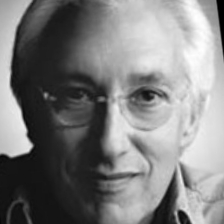

database3/database3/m.019pkm/91-FaceId-0_align.jpg 0.016 0.994


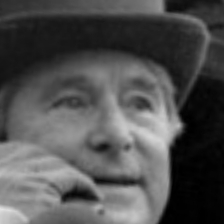

database3/database3/m.0183dl/55-FaceId-0_align.jpg 0.209 0.998


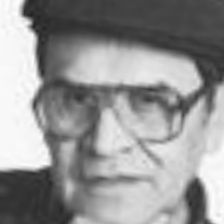

database3/database3/m.0197gg/7-FaceId-0_align.jpg 0.088 1.0


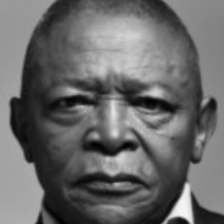

database3/database3/m.015t_m/70-FaceId-0_align.jpg 0.001 0.982


In [11]:
# Grayscale
for idx, row in df_train_grayscale[:5].iterrows():
    filename = row['filename']
    occlusion = row['FaceOcclusion']
    gender = row['gender']
    img2display = Image.open(f"{image_dir}/{filename}")
    display(img2display)
    print(filename, occlusion, gender)

In [12]:
df_train_color.head()

,filename,FaceOcclusion,gender,initial_index,gender_id,db_number,count,color,image_width,image_height,...,pixels,pixels_mean,pixels_mean_R,pixels_mean_G,pixels_mean_B,pixels_std,pixels_std_R,pixels_std_G,pixels_std_B,no_color
0,database1/img00015966.jpg,0.015,0.997,3803,1,1,1,1,224,224,...,50176,88.466724,131.119200,77.212532,57.068439,63.031255,63.500490,54.124863,45.002906,0
1,database3/database3/m.01bczm/134-FaceId-0_alig...,0.011,0.998,83938,1,3,1,1,224,224,...,50176,181.345258,211.715163,173.839943,158.480668,46.079777,31.835334,40.716520,46.874981,0
2,database3/database3/m.01bldq/0-FaceId-0_align.jpg,0.071,0.997,85474,1,3,1,1,224,224,...,50176,120.124821,143.054747,112.964525,104.355190,59.365307,65.384368,53.289036,51.304478,0
3,database1/img00017957.jpg,0.351,0.001,1978,0,1,1,1,224,224,...,50176,118.354479,151.092335,116.278819,87.692283,80.419840,84.658265,73.950982,68.920510,0
4,database1/img00020727.jpg,0.128,0.001,1200,0,1,1,1,224,224,...,50176,63.989411,93.894651,55.730349,42.343232,60.185922,77.639362,45.963021,35.992681,0


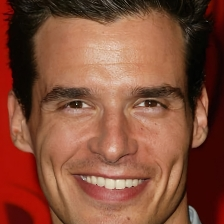

database1/img00015966.jpg 0.015 0.997


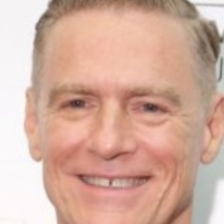

database3/database3/m.01bczm/134-FaceId-0_align.jpg 0.011 0.998


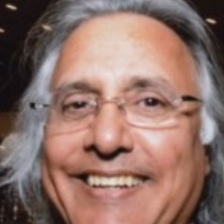

database3/database3/m.01bldq/0-FaceId-0_align.jpg 0.071 0.997


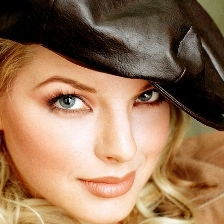

database1/img00017957.jpg 0.351 0.001


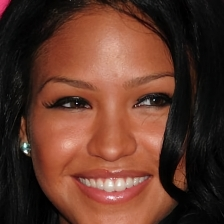

database1/img00020727.jpg 0.128 0.001


In [13]:
# Colors
for idx, row in df_train_color[:5].iterrows():
    filename = row['filename']
    occlusion = row['FaceOcclusion']
    gender = row['gender']
    img2display = Image.open(f"{image_dir}/{filename}")
    display(img2display)
    print(filename, occlusion, gender)

In [14]:
df_train_grayscale = df_train_grayscale.reset_index(drop=True)
df_train_color= df_train_color.reset_index(drop=True)

## Occlusion Range Categorization and Weighted Loss Preparation (The best choice : 10 classes)

In [15]:
bins = [0, 0.025, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 1.0]
labels = ['0-0.025', '0.025-0.05', '0.05-0.075', '0.075-0.1', '0.1-0.15', '0.15-0.2', '0.2-0.25', '0.25-0.3', '0.3-0.35', '>0.35']


df_train_grayscale['range'] = pd.cut(df_train_grayscale['FaceOcclusion'], bins=bins, labels=labels, include_lowest=True)
range_counts_G = df_train_grayscale['range'].value_counts().sort_index()
print(range_counts_G)

df_train_color['range'] = pd.cut(df_train_color['FaceOcclusion'], bins=bins, labels=labels, include_lowest=True)
range_counts = df_train_color['range'].value_counts().sort_index()
print(range_counts)


total_samples_G = len(df_train_grayscale)
total_samples = len(df_train_color)

range_weights_G = {label: 0.1*total_samples_G / count for label, count in range_counts_G.items()}
print("Weights for grayscale dataset")
print(range_weights_G)

range_weights = {label: 0.1*total_samples / count for label, count in range_counts.items()}
print("Weights for color dataset")
print(range_weights)

range
0-0.025       4336
0.025-0.05    2150
0.05-0.075    1150
0.075-0.1      850
0.1-0.15      1121
0.15-0.2       684
0.2-0.25       453
0.25-0.3       314
0.3-0.35       140
>0.35           70
Name: count, dtype: int64
range
0-0.025       21368
0.025-0.05    11388
0.05-0.075     7166
0.075-0.1      5713
0.1-0.15       8945
0.15-0.2       5849
0.2-0.25       3832
0.25-0.3       2767
0.3-0.35       1729
>0.35          1047
Name: count, dtype: int64
Weights for grayscale dataset
{'0-0.025': 0.2598708487084871, '0.025-0.05': 0.524093023255814, '0.05-0.075': 0.9798260869565217, '0.075-0.1': 1.3256470588235294, '0.1-0.15': 1.0051739518287244, '0.15-0.2': 1.6473684210526316, '0.2-0.25': 2.487417218543046, '0.25-0.3': 3.5885350318471336, '0.3-0.35': 8.048571428571428, '>0.35': 16.097142857142856}
Weights for color dataset
{'0-0.025': 0.3266754024709847, '0.025-0.05': 0.6129610115911486, '0.05-0.075': 0.9740999162712811, '0.075-0.1': 1.221844915105899, '0.1-0.15': 0.7803689211850197, '0.15-0

In [ ]:
model_grayscale = models.resnet18(pretrained=True)
model_grayscale.fc = nn.Linear(model_grayscale.fc.in_features, 1)
model_grayscale = model_grayscale.to(device)


# Loss function for grayscale model
criterion1 = WeightedMSELoss(range_weights_G)
# Loss function for color model
criterion2 = WeightedMSELoss(range_weights)

optimizer_grayscale = optim.Adam(model_grayscale.parameters(), lr=1e-4)

## Resnet with Grayscale 

In [36]:
num_epochs = 15
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    model_grayscale.train()
    running_loss = 0.0
    for batch_idx, (X, y, gender, filename) in tqdm(enumerate(train_grayscale_loader), total=len(train_grayscale_loader)):
        X, y = X.to(device), y.to(device).view(-1, 1)
        
        ranges = pd.cut(y.cpu().numpy().flatten(), bins=bins, labels=labels, include_lowest=True)
        
        optimizer_grayscale.zero_grad()
        y_pred = model_grayscale(X)
        #loss = criterion2(y_pred, y, ranges,gender)

        loss = criterion1(y_pred, y, ranges)

        loss.backward()
        optimizer_grayscale.step()
        running_loss += loss.item()

        if batch_idx % 2000 == 0:
            print(f"Batch {batch_idx}, Loss: {loss.item()}")

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_grayscale_loader)}")

print('Training complete for grayscale images')

c:\Users\ASUS\envs\virtual\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ASUS\envs\virtual\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/15


  0%|          | 4/1409 [00:00<02:02, 11.49it/s]

Batch 0, Loss: 0.2846342623233795


100%|██████████| 1409/1409 [00:45<00:00, 31.13it/s]


...

Epoch [14/15], Loss: 0.0007541068035840189
Epoch 15/15


  0%|          | 4/1409 [00:00<00:44, 31.70it/s]

Batch 0, Loss: 0.0023154565133154392


100%|██████████| 1409/1409 [00:44<00:00, 31.41it/s]

Epoch [15/15], Loss: 0.0008346680677250507
Training complete for grayscale images


# Resnet with color

In [37]:
model_color = models.resnet18(pretrained=True)
model_color.fc = nn.Linear(model_color.fc.in_features, 1)
model_color = model_color.to(device)

criterion2 = WeightedMSELoss(range_weights)

optimizer_color = optim.Adam(model_color.parameters(), lr=1e-4)

num_epochs = 15
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    model_color.train()
    running_loss = 0.0
    for batch_idx, (X, y, gender, filename) in tqdm(enumerate(train_color_loader), total=len(train_color_loader)):
        X, y = X.to(device), y.to(device).view(-1, 1)
        ranges = pd.cut(y.cpu().numpy().flatten(), bins=bins, labels=labels, include_lowest=True)

        optimizer_color.zero_grad()
        y_pred = model_color(X)
        #loss = criterion2(y_pred, y, ranges,gender)
        loss = criterion2(y_pred, y, range_weights)
        loss.backward()
        optimizer_color.step()
        running_loss += loss.item()
        
        if batch_idx % 2000 == 0:
            print(f"Batch {batch_idx}, Loss: {loss.item()}")

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_color_loader)}")

print('Training complete for color images')

c:\Users\ASUS\envs\virtual\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ASUS\envs\virtual\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/15


  0%|          | 0/8726 [00:00<?, ?it/s]

Batch 0, Loss: 1.0757917165756226

  0%|          | 3/8726 [00:00<05:05, 28.55it/s]

...

Batch 6000, Loss: 0.0001581827673362568


 92%|█████████▏| 8003/8726 [04:21<00:23, 30.62it/s]

Batch 8000, Loss: 0.00022636100766249


100%|██████████| 8726/8726 [04:44<00:00, 30.64it/s]

Epoch [15/15], Loss: 0.00032142945330040397
Training complete for color images


With range-based weight, result:  
epochs | best score  
3 | 0.016      
10 | 0.0013        
30 | 0.00089  
The score varies for same model and same epoch.
We also tried a prediction with grayscale model and normal model(to predict color image in order to have more robust) with 30 epochs training, values 0.00375.  


With range-gender-based weight, gender weights {'male': 1, 'female': 1.05} fine-tuning result:  
epochs | score  
10 | 0.0034 

# Seperate validation by color

In [ ]:
# Just use 'no_color' directly without creating 'is_grayscale'
df_val_grayscale = df_val[df_val['no_color'] == True].copy()
df_val_color = df_val[df_val['no_color'] == False].copy()

# Validation Prediction

In [ ]:
params_val = {
    'batch_size': 8,
    'shuffle': False,
    'num_workers': 0
}

val_loader = torch.utils.data.DataLoader(val_set, **params_val)

results_list = []
for batch_idx, (X, y, gender, filename, is_gray) in tqdm(enumerate(val_loader), total=len(val_loader)):
    X, y = X.to(device), y.to(device).view(-1, 1)
    y_preds = []
    
    for i in range(len(X)):  
        if is_gray[i].item(): 
            y_pred = model_grayscale(X[i].unsqueeze(0))  
        else:
            y_pred = model_color(X[i].unsqueeze(0)) 
        y_preds.append(y_pred.item())

    y_np = y.cpu().numpy().flatten()
    
    true_ranges = pd.cut(y_np, bins=bins, labels=labels, include_lowest=True)
    pred_ranges = pd.cut(y_preds, bins=bins, labels=labels, include_lowest=True)
    
    for i in range(len(X)):
        results_list.append({
            'true_range': str(true_ranges[i]), 
            'pred_range': str(pred_ranges[i]),
            'pred': float(y_preds[i]),
            'target': float(y_np[i]),
            'gender': float(gender[i])
        })

## Evaluate metric on validation split

100%|██████████| 2034/2034 [00:59<00:00, 34.13it/s]


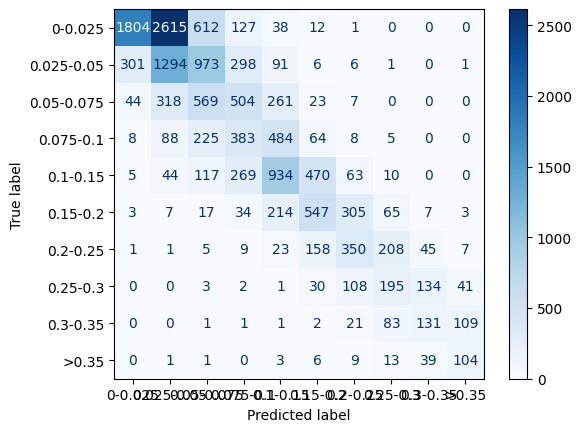

In [ ]:

results_list = []
for batch_idx, (X, y, gender, filename) in tqdm(enumerate(validation_generator), total=len(validation_generator)):
    X, y = X.to(device), y.to(device).view(-1, 1)
    y_pred = model(X)
    for i in range(len(X)):
        true_range = pd.cut([float(y[i])], bins=bins, labels=labels, include_lowest=True)[0]
        pred_range = pd.cut([float(y_pred[i])], bins=bins, labels=labels, include_lowest=True)[0]
        results_list.append({'true_range': str(true_range), 'pred_range': str(pred_range),'pred': float(y_pred[i]),
                                  'target': float(y[i]),
                                  'gender': float(gender[i])})


results_df = pd.DataFrame(results_list)

y_true = results_df['true_range']
y_pred = results_df['pred_range']
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(f"Classification Report:\n")
print(classification_report(y_true, y_pred, labels=labels, target_names=labels))


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [ ]:
print(f"Classification Report:\n")
print(classification_report(y_true, y_pred, labels=labels, target_names=labels))

Classification Report:

              precision    recall  f1-score   support

     0-0.025       0.83      0.34      0.48      5339
  0.025-0.05       0.30      0.43      0.35      2978
  0.05-0.075       0.23      0.33      0.27      1727
   0.075-0.1       0.24      0.30      0.26      1265
    0.1-0.15       0.46      0.49      0.47      1912
    0.15-0.2       0.42      0.46      0.43      1202
    0.2-0.25       0.40      0.43      0.42       807
    0.25-0.3       0.34      0.38      0.36       514
    0.3-0.35       0.37      0.38      0.37       349
       >0.35       0.39      0.59      0.47       176

   micro avg       0.39      0.39      0.39     16269
   macro avg       0.40      0.41      0.39     16269
weighted avg       0.50      0.39      0.40     16269



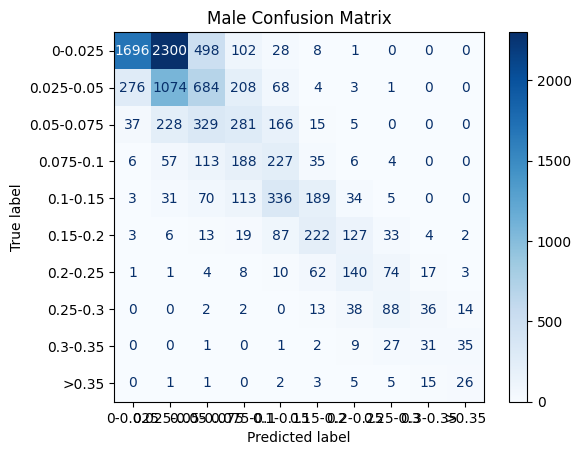

Classification Report for Male Confusion Matrix:

              precision    recall  f1-score   support

     0-0.025       0.84      0.36      0.50      4759
  0.025-0.05       0.29      0.46      0.36      2325
  0.05-0.075       0.19      0.31      0.24      1062
   0.075-0.1       0.20      0.30      0.24       636
    0.1-0.15       0.36      0.43      0.39       781
    0.15-0.2       0.40      0.43      0.42       516
    0.2-0.25       0.38      0.44      0.41       320
    0.25-0.3       0.37      0.46      0.41       193
    0.3-0.35       0.30      0.29      0.30       106
       >0.35       0.33      0.45      0.38        58

   micro avg       0.39      0.38      0.39     10756
   macro avg       0.37      0.39      0.36     10756
weighted avg       0.53      0.38      0.41     10756



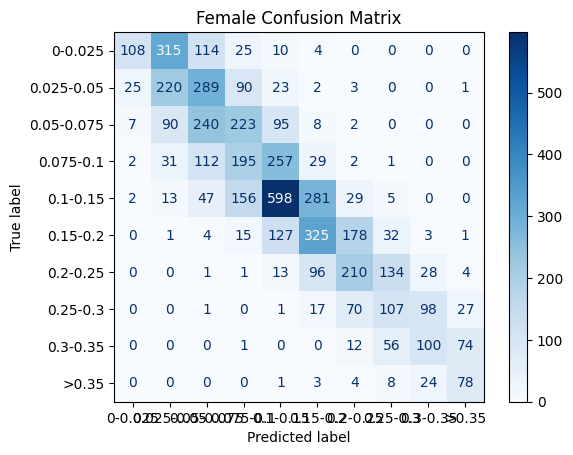

Classification Report for Female Confusion Matrix:

              precision    recall  f1-score   support

     0-0.025       0.75      0.19      0.30       580
  0.025-0.05       0.33      0.34      0.33       653
  0.05-0.075       0.30      0.36      0.33       665
   0.075-0.1       0.28      0.31      0.29       629
    0.1-0.15       0.53      0.53      0.53      1131
    0.15-0.2       0.42      0.47      0.45       686
    0.2-0.25       0.41      0.43      0.42       487
    0.25-0.3       0.31      0.33      0.32       321
    0.3-0.35       0.40      0.41      0.40       243
       >0.35       0.42      0.66      0.51       118

   micro avg       0.40      0.40      0.40      5513
   macro avg       0.41      0.40      0.39      5513
weighted avg       0.43      0.40      0.39      5513



In [ ]:
results_male = results_df.loc[results_df["gender"] > 0.5]
results_female = results_df.loc[results_df["gender"] < 0.5]
# print(results_male)
# print(results_female)

def plot_confusion_matrix(results, title):
    y_true = results['true_range']
    y_pred = results['pred_range']
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()
    
    print(f"Classification Report for {title}:\n")
    print(classification_report(y_true, y_pred, labels=labels, target_names=labels))


# Male confusion matrix
plot_confusion_matrix(results_male, "Male Confusion Matrix")

# Female confusion matrix
plot_confusion_matrix(results_female, "Female Confusion Matrix")

In [ ]:
metric_fn(results_male, results_female)

0.002332612480355155
0.0028553619690595594


0.0031167367134117617

## Evaluating your Test DataSet

test_set = Dataset(df_test, image_dir, include_labels=False)

test_set = Dataset(df_test, image_dir, include_labels=False)

params_test = {
    'batch_size': 8,
    'shuffle': False,
    'num_workers': 0
}

test_loader = torch.utils.data.DataLoader(test_set, **params_test)

results_list = []
for batch_idx, (X, filename) in tqdm(enumerate(test_loader), total=len(test_loader)):
    X = X.to(device)
    y_pred = model(X)

    for i in range(len(X)):
        results_list.append({
            'filename': filename[i],
            'pred': float(y_pred[i])
        })

test_df = pd.DataFrame(results_list)

In [ ]:
test_df.head()

,pred
0,0.280279
1,0.344143
2,0.361664
3,0.297884
4,0.383106


### Preparing your file for Submission

In [ ]:
test_df.to_csv("Data_Challenge.csv", header = None, index = None)